# Getting started with MemsArray object

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython import display

from megamicros.log import log
from megamicros.db.query import AidbSession
from megamicros.data import MuAudio, generate_moovie
from megamicros.core.base import MemsArray
from megamicros.bmf import Beamformer

log.setLevel( "INFO" )

## Getting signal from DB

In [2]:
# Available labels
LABEL_SOW_FEEDING_CALL = 18
LABEL_PIGLET_SQUEALS = 15
LABEL_SOW_GRUNT_NERVOUS = 16
LABEL_ROOM_NOISE = 29
LABEL_SOW_GRUNT = 8
LABEL_SOW_GRUNT_MODSTRESS  = 1
LABEL_SOW_SCREAMS = 3
LABEL_PIGLET_SQUEALS_2 = 5

# choose label, file and sequence in file:
LABEL_ID = LABEL_SOW_FEEDING_CALL
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0         

with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
        signal: MuAudio = session.load_labelized( 
            sourcefile_id=FILE_ID, 
            label_id=LABEL_ID, 
            limit=100, 
            channels=list( np.arange( 32 ) + 1 ) 
        )[SEQUENCE_ID]

# get infos
LABEL_TXT = signal.label
CHANNELS_NUMBER = signal.channels_number
SAMPLES_NUMBER = signal.samples_number
SAMPLING_FREQUENCY = signal.sampling_frequency

print( f"Some informations about the signal loaded:" )
print( f" > label={LABEL_TXT}" )
print( f" > channels_number={CHANNELS_NUMBER}" )
print( f" > samples_number={SAMPLES_NUMBER}" )
print( f" > sampling_frequency={SAMPLING_FREQUENCY}" )

# Play sound using channel 0 and 1
left = np.array( signal.channel(0) )
right = np.array( signal.channel(1) )
sound = np.array( [left, right] )

display.Audio(sound, rate=SAMPLING_FREQUENCY )

# Get the whole 32 channels signal as a numpy.ndarray
signal = signal().T

2023-09-11 22:42:39,728 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-09-11 22:42:40,124 [INFO]:  .Got HTTP 200 status code from server
2023-09-11 22:42:40,127 [INFO]:  .Received CSRF token: n7UOmuVzZtEoQ55yuPSbTHKV8ooGTk3m. Update session with
2023-09-11 22:42:40,127 [INFO]:  .Received session id: tzonuumagow22twgig853g2i55wmq4hf
2023-09-11 22:42:40,128 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-09-11 22:42:40,129 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-09-11 22:42:40,156 [INFO]:  .Found 4 labelized audio files
2023-09-11 22:42:40,157 [INFO]:  .Limit is set to 100 audio files
2023-09-11 22:42:40,158 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 22:42:40,221 [INFO]:  Object sourcefile found with identifier [8692] 
2023-09-11 22:42:44,982 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 22:42:45,041 [INFO]:  Object sourcefile

I'm a NDarray signal with frame size = 80860 and frame number = 1


2023-09-11 22:42:48,303 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 22:42:48,372 [INFO]:  Object sourcefile found with identifier [8692] 


I'm a NDarray signal with frame size = 54536 and frame number = 1


2023-09-11 22:42:51,083 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 22:42:51,156 [INFO]:  Object sourcefile found with identifier [8692] 


I'm a NDarray signal with frame size = 37671 and frame number = 1


2023-09-11 22:42:54,301 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-09-11 22:42:54,332 [INFO]:  .Logout successful.


I'm a NDarray signal with frame size = 67293 and frame number = 1
Some informations about the signal loaded:
 > label=sow-feeding-call
 > channels_number=32
 > samples_number=80860
 > sampling_frequency=10000.0


## Set the beamformer

2023-09-11 22:42:54,354 [INFO]:  .Set beamformer on a 25 MEMs antenna
2023-09-11 22:42:54,355 [INFO]:  .Set beamformer sampling rate on 10000.0 Hz
2023-09-11 22:42:54,355 [INFO]:  .Set beamformer FFT window size to 1024 samples
2023-09-11 22:42:54,356 [INFO]:  .Set beamformer space size to [12, 14, 0.01] meters
2023-09-11 22:42:54,356 [INFO]:  .Set beamformer space quantization to [4, 4, 100.0] locations/meter
2023-09-11 22:42:54,357 [INFO]:  .Move area from [0 0 0] to [ 0  0 -2]
2023-09-11 22:42:54,357 [INFO]:  .Checking beamformer parameters...
2023-09-11 22:42:54,358 [INFO]:  .[Ready]
2023-09-11 22:42:54,358 [INFO]:  .Found 2688 locations (48 x 56 x 1)
2023-09-11 22:42:54,358 [INFO]:  .Space quantum size is (0.25 x 0.25 x 0.01) meters
2023-09-11 22:42:54,369 [INFO]:  .Set beamformer band width to (0.02, 0.16)
2023-09-11 22:42:54,369 [INFO]:  .Checking beamformer parameters...
2023-09-11 22:42:54,370 [INFO]:  .[Ready]
2023-09-11 22:42:54,370 [INFO]:  .Beamformer2D Initilization:
2023

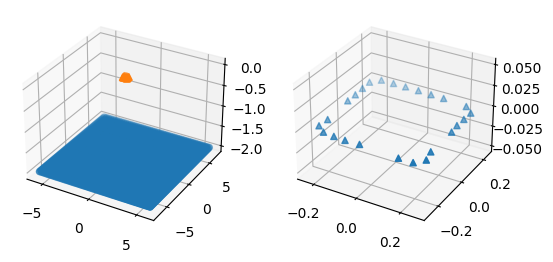

In [3]:
FRAME_LENGTH = 1024
AREA = [12, 14, 0.01]
AREA_QUANTIZATION = [4, 4, 1/0.01]

# Get the antenna physical description
antenna = np.load ('Antenna-square-JetsonNano-0001.npy', allow_pickle=True )
mems_position = antenna.item().get("positions")
mems = antenna.item().get('mems')
available_mems = antenna.item().get('available_mems')

# Check if some available mems have not been activated
# Remove from signal if any
if False in np.isin( available_mems, mems ):
    mask = list( np.invert( np.logical_not( np.isin( available_mems, mems ) ) ) )
    signal = signal[:,mask]

# Create the beamformer
bmf = Beamformer( 
    mems_position = mems_position,
    sampling_frequency = SAMPLING_FREQUENCY,
    window_size = FRAME_LENGTH,    
    area = AREA,
    area_quantization = AREA_QUANTIZATION
)

# Move the antenna in the right place:
bmf.moveArea( [0, 0, -2] )

# Limit the frequency bandwidth for BF computing
bmf.setBandWidth( [200, 2000], unit="frequency" )

# Init the beamformer
bmf.init()

# print area locations and antenna 
space_locations = bmf.getLocations()
mems_location = bmf.getMems()

fig = plt.figure()
ax = fig.add_subplot( 121, projection='3d' )
ax.scatter( space_locations[:,0], space_locations[:,1], space_locations[:,2] )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
ax = fig.add_subplot( 122, projection='3d' )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
fig.show()


## Compute preformed channels 

In [4]:
FRAMES_NUMBER = SAMPLES_NUMBER // FRAME_LENGTH - 1 

print( f"{FRAMES_NUMBER} frames of {FRAME_LENGTH} samples to perform... " )

nx, ny, nz = bmf.getLocationsNumber()

imgs = []
for i in range( FRAMES_NUMBER ):
    bf = bmf.beamform( signal[i*FRAME_LENGTH:(i+1)*FRAME_LENGTH,:] )
    imgs.append( np.reshape( bf, (nx, ny) ) )

77 frames of 1024 samples to perform... 


### Make video

2023-09-11 22:43:04,427 [INFO]:  .Create ./tmp directory...
2023-09-11 22:43:04,436 [INFO]:  .Generate images as png files without normalization...
2023-09-11 22:43:23,007 [INFO]:  .Generate video from png files...
2023-09-11 22:43:23,196 [INFO]:  .Generate sound wav file...


error: required argument is not an integer

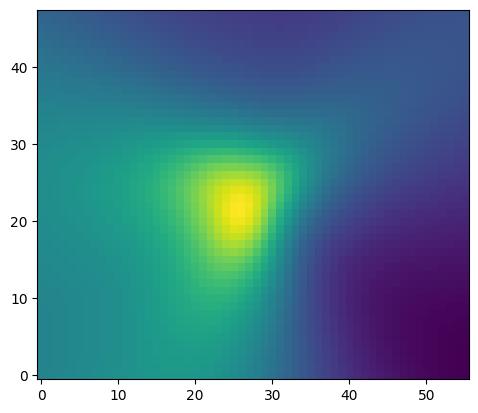

In [5]:
generate_moovie( 
    imgs, 
    rate=SAMPLING_FREQUENCY/FRAME_LENGTH, 
    sound=sound.astype( np.float32 ).T, 
    sampling_frequency=SAMPLING_FREQUENCY,
    norm=None,
    #extent=( 0, ROOM_SIZE[0], 0, ROOM_SIZE[1] ),
)

### Do the same with an antenna object

In [ ]:
# Declare a MEMs antenna
antenna = MemsArray( available_mems_number=CHANNELS_NUMBER )

# set active mems
antenna.setActiveMems( [i for i in range( CHANNELS_NUMBER )] )
print( f"active mems number={antenna.mems_number}" )

# iterate over the antenna data stream
#for i, data in enumerate( antenna ):
#    print( f"data={data}")
#    if i > 10:
#        break
